# Ablation — GPTQ vs Naive Quantization on 2D Matrices

Compares GPTQ (Hessian-based error compensation) against naive round-to-nearest quantization at different bitwidths.

| config | method | bitwidth |
|---|---|---|
| `naive_int8` | baseline naive rounding | int8 (±127) |
| `naive_int6` | baseline naive rounding | int6 (±31) |
| `naive_int4` | baseline naive rounding | int4 (±7) |
| `gptq_int8` | GPTQ | int8 (±127) |
| `gptq_int6` | GPTQ | int6 (±31) |
| `gptq_int4` | GPTQ | int4 (±7) |

## Goal

This ablation answers two questions:
1. **How much BPB does GPTQ recover** compared to naive rounding at the same bitwidth?
2. **Does GPTQ enable lower bitwidths?** Specifically, can GPTQ at int6 match or beat naive at int8?

Training is identical across all runs — only the post-training quantization method and bitwidth change. GPTQ uses 128 calibration sequences from the validation set and block size 128.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

BITS_ORDER = [8, 6, 4]
BITS_LABELS = {8: "int8", 6: "int6", 4: "int4"}

# Colors: naive in blue tones, GPTQ in green tones
NAIVE_COLOR = PALETTE[0]
GPTQ_COLOR  = PALETTE[2]

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\matte\_netrc.


## Original Baseline (3 seeds, reference)

In [2]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_SIZE_MEAN = df_base["quant_file_bytes"].mean()

print("=" * 55)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 55)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"file size     : {BASE_SIZE_MEAN / 1e6:.2f} MB")
print("=" * 55)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb : 1.3101 ± 0.0013
file size     : 15.78 MB


## Fetch Ablation Runs

In [3]:
# --- Fetch naive (2D matrices) runs ---
NAIVE_PREFIX = "golf_2d_matrices_quantization_ablation"

naive_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{NAIVE_PREFIX}"}},
))

naive_rows = []
for run in naive_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    naive_rows.append({
        "run_name":         run.name,
        "method":           "naive",
        "quant_bits":       bits,
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_naive = pd.DataFrame(naive_rows)
print(f"Fetched {len(df_naive)} naive runs.")
df_naive

Fetched 9 naive runs.


,run_name,method,quant_bits,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes
0,golf_2d_matrices_quantization_ablation_seed1337,naive,8,1337,1.306432,1.310132,2.212102,15768886
1,golf_2d_matrices_quantization_ablation_seed42,naive,8,42,1.307871,1.311658,2.214679,15775590
2,golf_2d_matrices_quantization_ablation_seed123,naive,8,123,1.305577,1.309140,2.210427,15790397
3,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,1337,1.306064,1.362489,2.300505,11896098
4,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,42,1.306980,1.364526,2.303944,11905424
5,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,123,1.304984,1.366342,2.307011,11903307
6,golf_2d_matrices_quantization_ablation_int4_se...,naive,4,1337,1.305906,2.259454,3.814994,7841982
7,golf_2d_matrices_quantization_ablation_int4_se...,naive,4,42,1.306976,2.215550,3.740863,7846052
8,golf_2d_matrices_quantization_ablation_int4_se...,naive,4,123,1.305626,2.245742,3.791842,7847991


In [4]:
# --- Fetch GPTQ runs ---
GPTQ_PREFIX = "GPTQ_MATRICES"

gptq_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{GPTQ_PREFIX}"}},
))

gptq_rows = []
for run in gptq_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", cfg.get("quant_bits", 8))

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    gptq_rows.append({
        "run_name":         run.name,
        "method":           "gptq",
        "quant_bits":       bits,
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_gptq = pd.DataFrame(gptq_rows)
print(f"Fetched {len(df_gptq)} GPTQ runs.")
df_gptq

Fetched 9 GPTQ runs.


,run_name,method,quant_bits,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes
0,GPTQ_MATRICES_seed1337,gptq,6,1337,1.306296,1.364889,2.304558,11896932
1,GPTQ_MATRICES_seed42,gptq,6,42,1.308099,1.367217,2.308489,11897277
2,GPTQ_MATRICES_seed123,gptq,6,123,1.305630,1.362232,2.300072,11906305
3,GPTQ_MATRICES_seed1337,gptq,4,1337,1.306326,2.105418,3.554910,7850221
4,GPTQ_MATRICES_seed42,gptq,4,42,1.307331,2.203581,3.720654,7855540
5,GPTQ_MATRICES_seed123,gptq,4,123,1.305189,2.144190,3.620376,7868664
6,GPTQ_MATRICES_seed1337,gptq,8,1337,1.306735,1.310361,2.212490,15767242
7,GPTQ_MATRICES_seed42,gptq,8,42,1.307448,1.311094,2.213727,15773851
8,GPTQ_MATRICES_seed123,gptq,8,123,1.305504,1.309179,2.210494,15783429


In [5]:
# --- Combine and compute deltas ---
df = pd.concat([df_naive, df_gptq], ignore_index=True)
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

df = (
    df.assign(bits_order=df["quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values(["bits_order", "method"])
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

df

,run_name,method,quant_bits,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes,delta_bpb
0,GPTQ_MATRICES_seed1337,gptq,8,1337,1.306735,1.310361,2.212490,15767242,0.003626
1,GPTQ_MATRICES_seed42,gptq,8,42,1.307448,1.311094,2.213727,15773851,0.003646
2,GPTQ_MATRICES_seed123,gptq,8,123,1.305504,1.309179,2.210494,15783429,0.003675
3,golf_2d_matrices_quantization_ablation_seed1337,naive,8,1337,1.306432,1.310132,2.212102,15768886,0.003700
4,golf_2d_matrices_quantization_ablation_seed42,naive,8,42,1.307871,1.311658,2.214679,15775590,0.003787
5,golf_2d_matrices_quantization_ablation_seed123,naive,8,123,1.305577,1.309140,2.210427,15790397,0.003563
6,GPTQ_MATRICES_seed1337,gptq,6,1337,1.306296,1.364889,2.304558,11896932,0.058593
7,GPTQ_MATRICES_seed42,gptq,6,42,1.308099,1.367217,2.308489,11897277,0.059118
8,GPTQ_MATRICES_seed123,gptq,6,123,1.305630,1.362232,2.300072,11906305,0.056602
9,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,1337,1.306064,1.362489,2.300505,11896098,0.056425


### Round-trip BPB: Naive vs GPTQ at each bitwidth

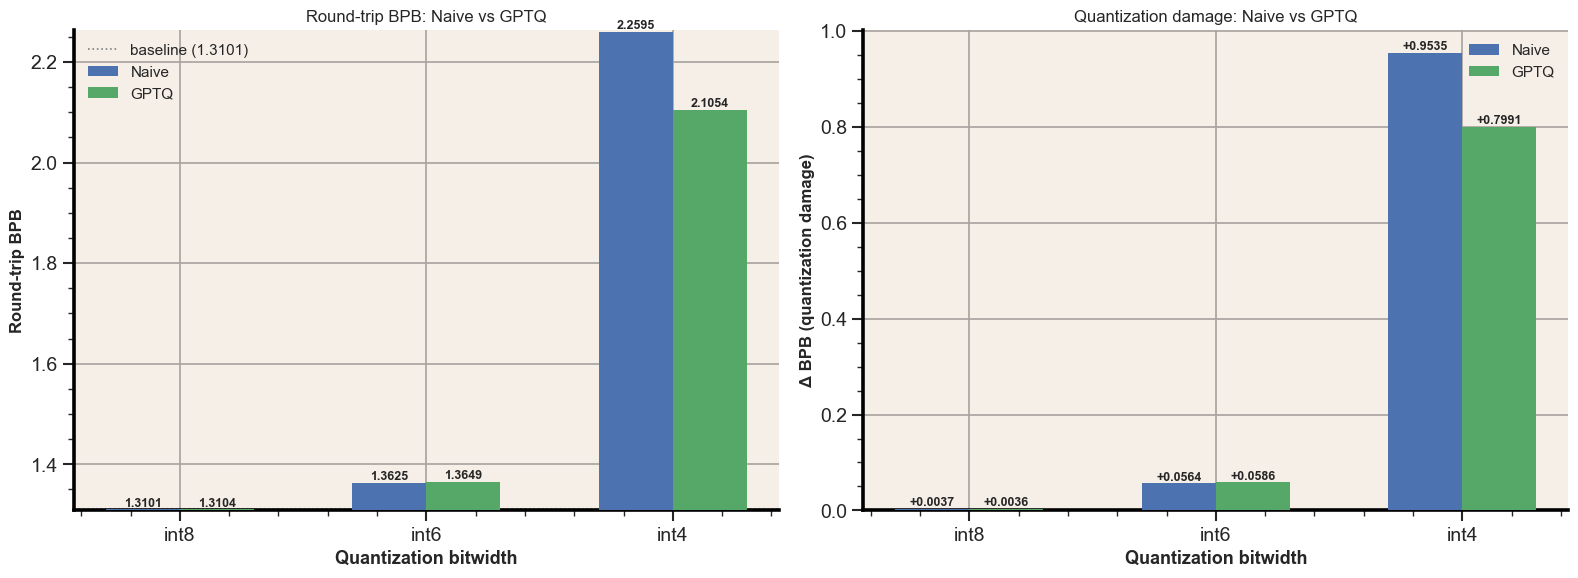

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bits_vals = [b for b in BITS_ORDER
             if b in df_naive["quant_bits"].values
             and b in df_gptq["quant_bits"].values]

x = np.arange(len(bits_vals))
width = 0.3

# --- Round-trip BPB ---
ax = axes[0]
bpb_naive = [df_naive.loc[df_naive["quant_bits"] == b, "final_val_bpb"].values[0]
             for b in bits_vals]
bpb_gptq  = [df_gptq.loc[df_gptq["quant_bits"] == b, "final_val_bpb"].values[0]
             for b in bits_vals]

bars1 = ax.bar(x - width/2, bpb_naive, width, label="Naive", color=NAIVE_COLOR, zorder=3)
bars2 = ax.bar(x + width/2, bpb_gptq,  width, label="GPTQ",  color=GPTQ_COLOR, zorder=3)

for bar_group, bpbs in [(bars1, bpb_naive), (bars2, bpb_gptq)]:
    for bar, bpb in zip(bar_group, bpbs):
        ax.text(bar.get_x() + bar.get_width()/2, bpb + 0.0003, f"{bpb:.4f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("Round-trip BPB: Naive vs GPTQ", fontsize=12)
ax.legend(fontsize=11)

ymin = min(bpb_naive + bpb_gptq) - 0.002
ymax = max(bpb_naive + bpb_gptq) + 0.004
ax.set_ylim(ymin, ymax)

# --- Delta (quantization damage) ---
ax = axes[1]
delta_naive = [df_naive.loc[df_naive["quant_bits"] == b, "final_val_bpb"].values[0]
               - df_naive.loc[df_naive["quant_bits"] == b, "fp32_val_bpb"].values[0]
               for b in bits_vals]
delta_gptq  = [df_gptq.loc[df_gptq["quant_bits"] == b, "final_val_bpb"].values[0]
               - df_gptq.loc[df_gptq["quant_bits"] == b, "fp32_val_bpb"].values[0]
               for b in bits_vals]

bars1 = ax.bar(x - width/2, delta_naive, width, label="Naive", color=NAIVE_COLOR, zorder=3)
bars2 = ax.bar(x + width/2, delta_gptq,  width, label="GPTQ",  color=GPTQ_COLOR, zorder=3)

for bar_group, deltas in [(bars1, delta_naive), (bars2, delta_gptq)]:
    for bar, d in zip(bar_group, deltas):
        ax.text(bar.get_x() + bar.get_width()/2, d + 0.0003, f"{d:+.4f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("Quantization damage: Naive vs GPTQ", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout(pad=1.5)
plt.show()

### Compressed file size comparison

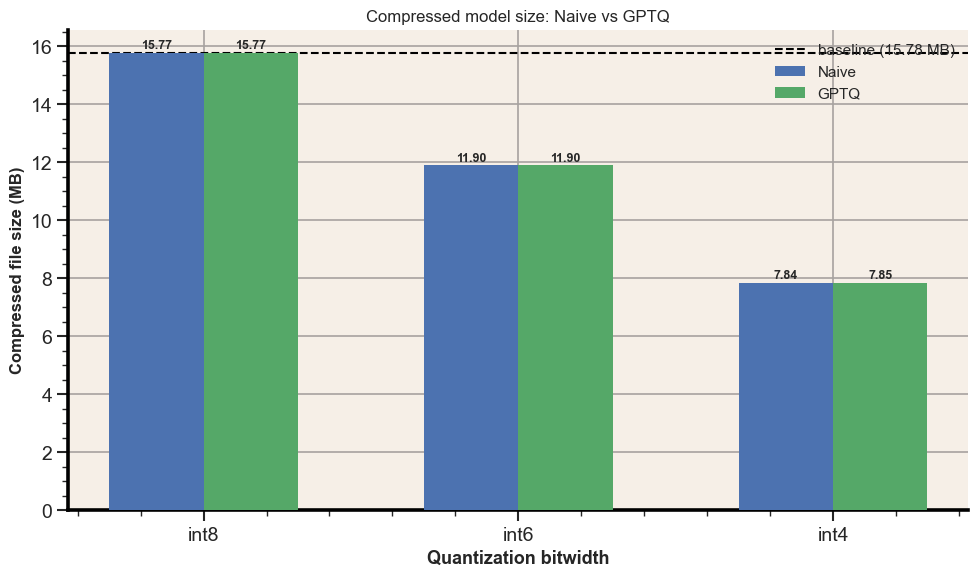

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

size_naive = [df_naive.loc[df_naive["quant_bits"] == b, "quant_file_bytes"].values[0] / 1e6
              for b in bits_vals]
size_gptq  = [df_gptq.loc[df_gptq["quant_bits"] == b, "quant_file_bytes"].values[0] / 1e6
              for b in bits_vals]

bars1 = ax.bar(x - width/2, size_naive, width, label="Naive", color=NAIVE_COLOR, zorder=3)
bars2 = ax.bar(x + width/2, size_gptq,  width, label="GPTQ",  color=GPTQ_COLOR, zorder=3)

for bar_group, sizes in [(bars1, size_naive), (bars2, size_gptq)]:
    for bar, mb in zip(bar_group, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, mb + 0.03, f"{mb:.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASE_SIZE_MEAN / 1e6, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline ({BASE_SIZE_MEAN / 1e6:.2f} MB)")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("Compressed model size: Naive vs GPTQ", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### Tradeoff: BPB vs compressed size

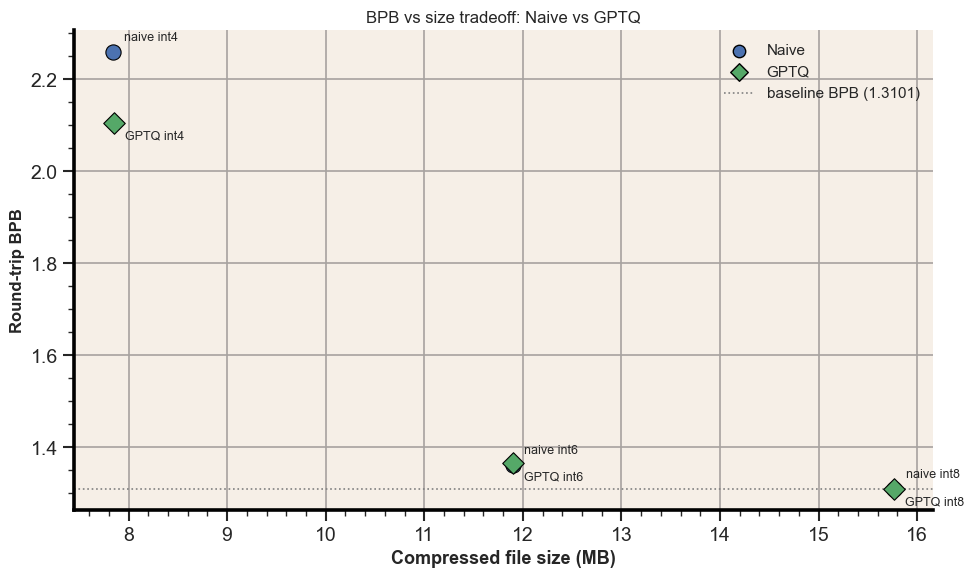

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for b in bits_vals:
    # Naive point
    row_n = df_naive[df_naive["quant_bits"] == b].iloc[0]
    ax.scatter(row_n["quant_file_bytes"] / 1e6, row_n["final_val_bpb"],
               color=NAIVE_COLOR, s=120, zorder=5, marker="o",
               edgecolors="black", linewidth=0.8)
    ax.annotate(f"naive {BITS_LABELS[b]}",
                (row_n["quant_file_bytes"] / 1e6, row_n["final_val_bpb"]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

    # GPTQ point
    row_g = df_gptq[df_gptq["quant_bits"] == b].iloc[0]
    ax.scatter(row_g["quant_file_bytes"] / 1e6, row_g["final_val_bpb"],
               color=GPTQ_COLOR, s=120, zorder=5, marker="D",
               edgecolors="black", linewidth=0.8)
    ax.annotate(f"GPTQ {BITS_LABELS[b]}",
                (row_g["quant_file_bytes"] / 1e6, row_g["final_val_bpb"]),
                textcoords="offset points", xytext=(8, -12), fontsize=9)

# Add legend entries
ax.scatter([], [], color=NAIVE_COLOR, s=80, marker="o", edgecolors="black", label="Naive")
ax.scatter([], [], color=GPTQ_COLOR,  s=80, marker="D", edgecolors="black", label="GPTQ")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline BPB ({BASE_BPB_MEAN:.4f})")

ax.set_xlabel("Compressed file size (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("BPB vs size tradeoff: Naive vs GPTQ", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### GPTQ improvement over Naive at each bitwidth

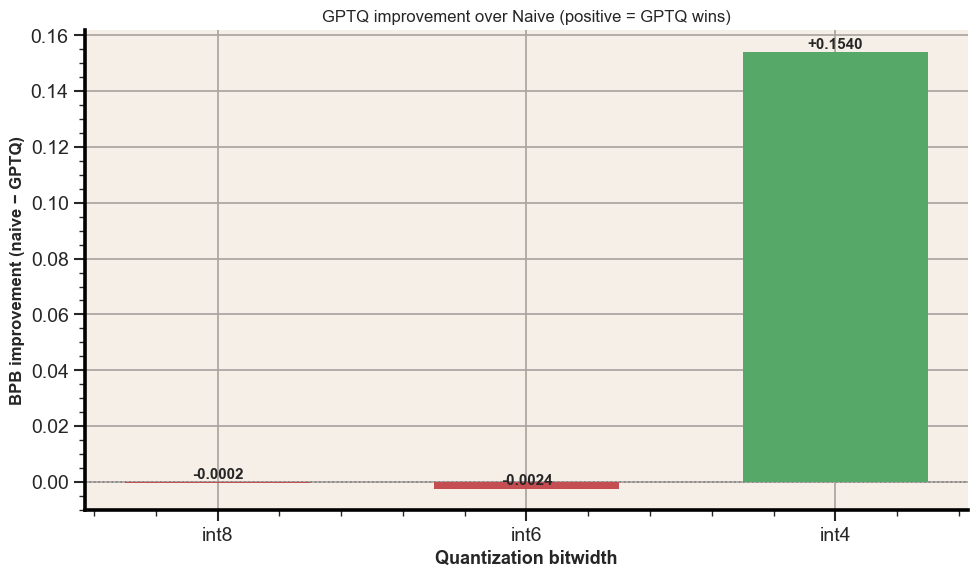

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

improvements = []
for b in bits_vals:
    naive_bpb = df_naive.loc[df_naive["quant_bits"] == b, "final_val_bpb"].values[0]
    gptq_bpb  = df_gptq.loc[df_gptq["quant_bits"] == b, "final_val_bpb"].values[0]
    improvements.append(naive_bpb - gptq_bpb)

colors = [GPTQ_COLOR if imp > 0 else PALETTE[3] for imp in improvements]
ax.bar(range(len(bits_vals)), improvements, color=colors, width=0.6, zorder=3)

for i, (b, imp) in enumerate(zip(bits_vals, improvements)):
    ax.text(i, imp + 0.0002, f"{imp:+.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("BPB improvement (naive − GPTQ)", fontsize=12)
ax.set_title("GPTQ improvement over Naive (positive = GPTQ wins)", fontsize=12)
plt.tight_layout(pad=1.5)
plt.show()

### Summary table

In [10]:
rows_summary = [{
    "config":          "Original baseline (3 seeds)",
    "method":          "—",
    "val_bpb":         BASE_BPB_MEAN,
    "val_bpb_std":     BASE_BPB_STD,
    "delta_bpb":       float("nan"),
    "Δ vs baseline":   0.0,
    "file_size_MB":    BASE_SIZE_MEAN / 1e6,
}]

for b in BITS_ORDER:
    # Naive
    sub_n = df_naive[df_naive["quant_bits"] == b]
    if not sub_n.empty:
        row = sub_n.iloc[0]
        rows_summary.append({
            "config":         f"{BITS_LABELS[b]}",
            "method":         "naive",
            "val_bpb":        row["final_val_bpb"],
            "val_bpb_std":    float("nan"),
            "delta_bpb":      row["final_val_bpb"] - row["fp32_val_bpb"],
            "Δ vs baseline":  row["final_val_bpb"] - BASE_BPB_MEAN,
            "file_size_MB":   row["quant_file_bytes"] / 1e6,
        })

    # GPTQ
    sub_g = df_gptq[df_gptq["quant_bits"] == b]
    if not sub_g.empty:
        row = sub_g.iloc[0]
        rows_summary.append({
            "config":         f"{BITS_LABELS[b]}",
            "method":         "GPTQ",
            "val_bpb":        row["final_val_bpb"],
            "val_bpb_std":    float("nan"),
            "delta_bpb":      row["final_val_bpb"] - row["fp32_val_bpb"],
            "Δ vs baseline":  row["final_val_bpb"] - BASE_BPB_MEAN,
            "file_size_MB":   row["quant_file_bytes"] / 1e6,
        })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"]      = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["val_bpb_std"]  = df_summary["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary["delta_bpb"]    = df_summary["delta_bpb"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")
df_summary["Δ vs baseline"] = df_summary["Δ vs baseline"].map(lambda x: f"{x:+.4f}")
df_summary["file_size_MB"] = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}")

print(df_summary.to_string(index=False))

# Key findings
print("\n" + "=" * 70)
for b in bits_vals:
    sub_n = df_naive[df_naive["quant_bits"] == b]
    sub_g = df_gptq[df_gptq["quant_bits"] == b]
    if not sub_n.empty and not sub_g.empty:
        imp = sub_n.iloc[0]["final_val_bpb"] - sub_g.iloc[0]["final_val_bpb"]
        print(f"{BITS_LABELS[b]}: GPTQ {'improves' if imp > 0 else 'worsens'} BPB by {abs(imp):.4f}")

# Cross-bitwidth comparison
print("\n--- Cross-bitwidth comparison ---")
if 8 in df_naive["quant_bits"].values and 6 in df_gptq["quant_bits"].values:
    naive8_bpb = df_naive.loc[df_naive["quant_bits"] == 8, "final_val_bpb"].values[0]
    gptq6_bpb  = df_gptq.loc[df_gptq["quant_bits"] == 6, "final_val_bpb"].values[0]
    naive8_size = df_naive.loc[df_naive["quant_bits"] == 8, "quant_file_bytes"].values[0] / 1e6
    gptq6_size  = df_gptq.loc[df_gptq["quant_bits"] == 6, "quant_file_bytes"].values[0] / 1e6
    diff = naive8_bpb - gptq6_bpb
    print(f"Naive int8: {naive8_bpb:.4f} BPB, {naive8_size:.2f} MB")
    print(f"GPTQ  int6: {gptq6_bpb:.4f} BPB, {gptq6_size:.2f} MB")
    if diff > 0:
        print(f"→ GPTQ int6 beats naive int8 by {diff:.4f} BPB while being {naive8_size - gptq6_size:.2f} MB smaller!")
    else:
        print(f"→ GPTQ int6 is {-diff:.4f} BPB worse than naive int8, but {naive8_size - gptq6_size:.2f} MB smaller.")

                     config method val_bpb val_bpb_std delta_bpb Δ vs baseline file_size_MB
Original baseline (3 seeds)      —  1.3101     ±0.0013         —       +0.0000        15.78
                       int8  naive  1.3101           —   +0.0037       +0.0000        15.77
                       int8   GPTQ  1.3104           —   +0.0036       +0.0003        15.77
                       int6  naive  1.3625           —   +0.0564       +0.0524        11.90
                       int6   GPTQ  1.3649           —   +0.0586       +0.0548        11.90
                       int4  naive  2.2595           —   +0.9535       +0.9494         7.84
                       int4   GPTQ  2.1054           —   +0.7991       +0.7953         7.85

int8: GPTQ worsens BPB by 0.0002
int6: GPTQ worsens BPB by 0.0024
int4: GPTQ improves BPB by 0.1540

--- Cross-bitwidth comparison ---
Naive int8: 1.3101 BPB, 15.77 MB
GPTQ  int6: 1.3649 BPB, 11.90 MB
→ GPTQ int6 is 0.0548 BPB worse than naive int8, but 3.87 MB s